# Assignment 5 : SVM Regressor

### <font color='pink'>**A quick note on SVR:**
Support Vector Regression extends the same margin-based idea from SVM classification to continuous targets. Instead of maximizing the margin between classes, SVR fits a function within an **ε-insensitive tube** around the data — predictions within ε of the true value incur zero loss, and only points *outside* the tube contribute to the loss, weighted by C:$$f(x) = \sum_i (\alpha_i - \alpha_i^*)\, K(x_i, x) + b$$where $K$ is the kernel (linear: $K(x,x')=x \cdot x'$; RBF: $K(x,x')=\exp(-\gamma\|x-x'\|^2)$). $C$ controls the trade-off between a flatter/simpler function and tolerating fewer points outside the tube (larger $C$ → less tolerance, tighter fit to training data); $\varepsilon$ controls how wide that zero-loss tube is (larger $\varepsilon$ → more tolerance for small errors, but potentially more bias). $\gamma$ (RBF only) controls how far each training point's influence reaches, same role as in SVC.

### <font color='pink'>A Quick Look at the Kernel Trick
Many algorithms, including SVMs, only ever need to compute **dot products** between data points — never the points themselves. The kernel trick exploits this: instead of explicitly transforming data into a higher-dimensional space where it becomes linearly separable, we compute a kernel function $K(x, x')$ that equals the dot product of the transformed points, *without ever computing the transformation itself*. **A concrete toy example.** Take 2D points $x = (x_1, x_2)$, and define the mapping $\varphi(x) = (x_1^2,\ \sqrt{2}\,x_1 x_2,\ x_2^2)$, lifting each point into 3D. It turns out that:$$\varphi(x) \cdot \varphi(x') = (x_1 x_1' + x_2 x_2')^2 = (x \cdot x')^2$$So instead of explicitly computing $\varphi(x)$ and $\varphi(x')$ (3 numbers each) and then their dot product, we can just compute $(x \cdot x')^2$ directly on the original 2D points — this *is* the polynomial kernel of degree 2. Same result, far less computation, and the trick scales to spaces with far more dimensions (even infinite, as with the RBF kernel) where explicitly computing $\varphi(x)$ wouldn't be feasible at all.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Task-0 (ungraded)

Pick any two 2D points $x = (x_1, x_2)$ and $x' = (x_1', x_2')$. Write code to:

0.1. Compute $\varphi(x)$ and $\varphi(x')$ explicitly using the mapping above, then take their dot product.

0.2. Compute $(x \cdot x')^2$ directly on the original points. Confirm both give the same result.

In [2]:
phi = lambda x : np.array([x[0] ** 2, np.sqrt(2) * x[0] * x[1], x[1] ** 2])
x = (2, 3)
x_prime = (4, 5)

# compute phi(x) and phi(x'), then take their dot product
result_1 = np.dot(phi(x), phi(x_prime))

# compute (x, x')^ 2 directly on original points
result_2 = np.dot(x, x_prime) ** 2

print("phi(x) · phi(x') =", result_1)
print("(x · x')²        =", result_2)
print("Same result      =", np.isclose(result_1, result_2))

phi(x) · phi(x') = 529.0
(x · x')²        = 529
Same result      = True


### Task-1: [1 marks]

1.1. Load the [Energy Efficiency dataset](https://archive.ics.uci.edu/dataset/242/energy+efficiency) from UCI. Use `Y1` (Heating Load) as the regression target. [0.5 marks]

1.2. Split the dataset into training, validation and test sets (70%-15%-15%). [0.5 marks]

In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"
data = pd.read_excel(url)
df = pd.DataFrame(data)
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [4]:
y = df['Y1']
x = df.drop(columns=['Y1', 'Y2'])
print("Feature shape:", x.shape)
print("Target shape:", y.shape)

Feature shape: (768, 8)
Target shape: (768,)


In [5]:
from sklearn.model_selection import train_test_split

# train : val : test = 70 : 15 : 15 split
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.3, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

print(f"Shape of training dataset: x = {x_train.shape}, y = {y_train.shape}")
print(f"Shape of validation dataset: x = {x_val.shape}, y = {y_val.shape}")
print(f"Shape of testing dataset: x = {x_test.shape}, y = {y_test.shape}")

Shape of training dataset: x = (537, 8), y = (537,)
Shape of validation dataset: x = (115, 8), y = (115,)
Shape of testing dataset: x = (116, 8), y = (116,)


### Task-2: [2 marks]

2.1. Perform feature scaling such that the features lie in the same range of values. [1 marks]

2.2. Show the correlation between the features of the training set. [1 marks]

In [6]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# fit only on training data
x_train_scaled = scaler.fit_transform(x_train)

# use the same scaler for val and test data
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

# before and after scaling comparison
comparison = pd.DataFrame({
    "Original Min": x_train.min(),
    "Original Max": x_train.max(),
    "Scaled Min": x_train_scaled.min(),
    "Scaled Max": x_train_scaled.max()
}, index=x_train.columns)
display(comparison)

,Original Min,Original Max,Scaled Min,Scaled Max
X1,0.62,0.98,0.0,1.0
X2,514.50,808.50,0.0,1.0
X3,245.00,416.50,0.0,1.0
X4,110.25,220.50,0.0,1.0
X5,3.50,7.00,0.0,1.0
X6,2.00,5.00,0.0,1.0
X7,0.00,0.40,0.0,1.0
X8,0.00,5.00,0.0,1.0


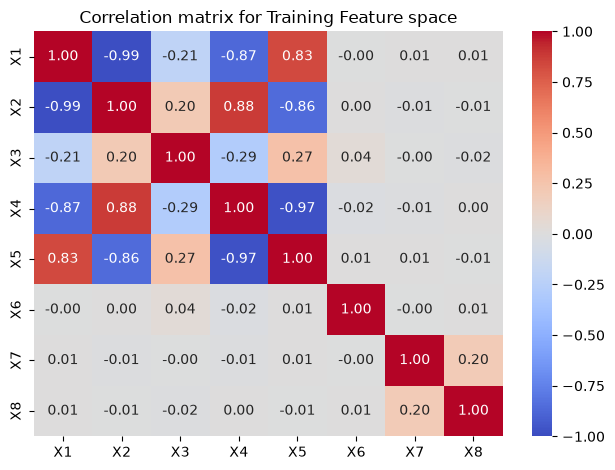

In [7]:
# correlation in training dataset
corr = x_train.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix for Training Feature space")
plt.tight_layout()
plt.savefig('plots/corr_heatmap.png')

### Task-3: [5 marks]

3.1. Fit an SVM with linear kernel on the training set using sklearn's SVR. [2 marks]

3.2. Tune the hyperparameters C and ε on the validation set using grid search (Take range of values of C and ε as provided below). [3 marks]
- C = 0.01, 0.1, 1, 10, 100
- ε = 0.001, 0.01, 0.1, 0.5, 1.0

In [8]:
from sklearn.svm import SVR

svr_linear = SVR(kernel='linear')
svr_linear.fit(x_train_scaled, y_train)
svr_linear

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [9]:
from sklearn.metrics import root_mean_squared_error

C_values = [0.01, 0.1, 1, 10, 100]              # error penalty
epsilon_values = [0.001, 0.01, 0.1, 0.5, 1.0]   # error tolerance
results = []

# grid search for all values of C and epsilon
for C in C_values:
    for epsilon in epsilon_values:
        model = SVR(kernel='linear', C=C, epsilon=epsilon)
        model.fit(x_train_scaled, y_train)
        y_val_pred = model.predict(x_val_scaled)
        rmse = root_mean_squared_error(y_val, y_val_pred)
        results.append({
            "C": C,
            "epsilon": epsilon,
            "Validation RMSE": rmse
        })
        
results = pd.DataFrame(results)
results = results.sort_values(by="Validation RMSE").reset_index(drop=True)
display(results)

,C,epsilon,Validation RMSE
0,100.00,1.000,3.217375
1,10.00,1.000,3.239628
2,100.00,0.500,3.253496
3,10.00,0.500,3.274244
4,100.00,0.001,3.276028
5,100.00,0.010,3.276253
6,10.00,0.010,3.286067
7,10.00,0.001,3.286528
8,10.00,0.100,3.288264
9,100.00,0.100,3.290070


In [10]:
# pick the hyperparameters with lowest validation RMSE
best_params = results.iloc[0]
best_C = best_params["C"]
best_epsilon = best_params["epsilon"]

print("Best C:", best_C)
print("Best epsilon:", best_epsilon)
print(f"Best Validation RMSE: {best_params['Validation RMSE']:.4f}")

Best C: 100.0
Best epsilon: 1.0
Best Validation RMSE: 3.2174


### Task-4: [3 marks]

4.1. Evaluate the linear SVM regressor using the best value of C and ε you obtained. Report the performance in terms of MSE and R^2 score. [1 marks]

4.2. Show a scatter plot of the predictions of the linear SVR model vs. the ground truth target values. [2 marks]

In [11]:
from sklearn.metrics import mean_squared_error, r2_score

best_linear_svm = SVR(kernel='linear', C=best_C, epsilon=best_epsilon)
best_linear_svm.fit(x_train_scaled, y_train)
y_test_pred = best_linear_svm.predict(x_test_scaled)

mse = mean_squared_error(y_test, y_test_pred)
r2s = r2_score(y_test, y_test_pred)
print(f"Mean squared error = {mse:.4f}")
print(f"R^2 score = {r2s:.4f}")

Mean squared error = 7.7996
R^2 score = 0.9204


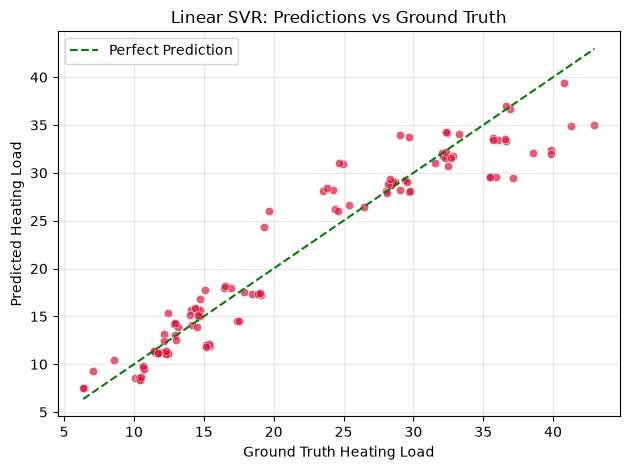

In [12]:
# determine plot range
min_val, max_val = min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max()) 

# scatter plot of predictions vs truth values
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.7, color='crimson')              
plt.plot([min_val, max_val], [min_val, max_val], '--', label="Perfect Prediction", color='green') 

plt.title("Linear SVR: Predictions vs Ground Truth")  
plt.xlabel("Ground Truth Heating Load")                          
plt.ylabel("Predicted Heating Load")                                        
plt.legend()                                                     
plt.grid(alpha=0.3)                                              
plt.tight_layout()
plt.savefig("plots/linear_svr_pred_vs_truth.png")

**Observations**

The tuned linear SVR achieved a test `MSE of 7.7996` and an `R^2 score of 0.9204`, indicating that the model ***explains approximately 92.04% of the variation*** in Heating Load on the unseen test data.

### Task-5: [6 marks]

5.1. Fit an SVM with RBF kernel on the training set using sklearn's SVR. [2 marks]

5.2. Tune the hyperparameters C, γ and ε on the validation set using grid search (Take range of values of C, γ and ε as provided below). [4 marks]
- C = 0.1, 1, 10, 100, 1000
- γ = 0.001, 0.01, 0.1, 1, 10
- ε = 0.01, 0.1, 0.5, 1.0

In [13]:
rbf_svm = SVR(kernel='rbf')
rbf_svm.fit(x_train_scaled, y_train)
rbf_svm

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [14]:
C_values = [0.1, 1, 10, 100, 1000]          # error penalty
gamma_values = [0.001, 0.01, 0.1, 1, 10]    # influence of each training point
epsilon_values = [0.01, 0.1, 0.5, 1.0]      # error tolerance
results = []

# grid search for all values of C, gamma and epsilon
for C in C_values:
    for gamma in gamma_values:
        for epsilon in epsilon_values:
            model = SVR(kernel='rbf', C=C, epsilon=epsilon, gamma=gamma)
            model.fit(x_train_scaled, y_train)
            y_val_pred = model.predict(x_val_scaled)
            rmse = root_mean_squared_error(y_val, y_val_pred)
            results.append({
                "C": C,
                "gamma": gamma,
                "epsilon": epsilon,
                "Validation RMSE": rmse
            })

results = pd.DataFrame(results)
results = results.sort_values(by="Validation RMSE").reset_index(drop=True)
display(results)

,C,gamma,epsilon,Validation RMSE
0,1000.0,1.000,0.01,0.613605
1,1000.0,1.000,0.10,0.624487
2,1000.0,1.000,0.50,0.794686
3,1000.0,1.000,1.00,1.072298
4,100.0,1.000,1.00,2.005643
...,...,...,...,...
95,0.1,0.010,0.01,11.511062
96,0.1,0.001,1.00,11.747134
97,0.1,0.001,0.50,11.902040
98,0.1,0.001,0.10,12.117448


In [15]:
# pick the hyperparameters with lowest validation RMSE
best_params = results.iloc[0]
best_C = best_params["C"]
best_gamma = best_params["gamma"]
best_epsilon = best_params["epsilon"]

print("Best C:", best_C)
print("Best gamma:", best_gamma)
print("Best epsilon:", best_epsilon)
print(f"Best Validation RMSE: {best_params['Validation RMSE']:.4f}")

Best C: 1000.0
Best gamma: 1.0
Best epsilon: 0.01
Best Validation RMSE: 0.6136


### Task-6: [3 marks]

6.1. Evaluate the RBF SVM regressor using the best value of C, γ and ε you obtained. Report the performance in terms of MSE and R^2 score. [1 marks]

6.2. Show a scatter plot of the predictions of the RBF SVR model vs. the ground truth target values. [2 marks]

In [16]:
best_rbf_svm = SVR(kernel='rbf', C=best_C, epsilon=best_epsilon, gamma=best_gamma)
best_rbf_svm.fit(x_train_scaled, y_train)
y_test_pred = best_rbf_svm.predict(x_test_scaled)

mse = mean_squared_error(y_test, y_test_pred)
r2s = r2_score(y_test, y_test_pred)
print(f"Mean squared error = {mse:.4f}")
print(f"R^2 score = {r2s:.4f}")

Mean squared error = 0.3912
R^2 score = 0.9960


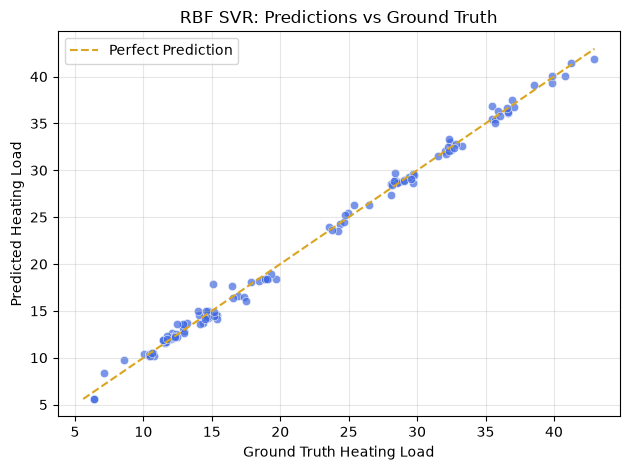

In [17]:
# determine plot range
min_val, max_val = min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max()) 

# scatter plot of predictions vs truth values
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.7, color='royalblue')              
plt.plot([min_val, max_val], [min_val, max_val], '--', label="Perfect Prediction", color='goldenrod') 

plt.title("RBF SVR: Predictions vs Ground Truth")  
plt.xlabel("Ground Truth Heating Load")                          
plt.ylabel("Predicted Heating Load")                                        
plt.legend()                                                     
plt.grid(alpha=0.3)                                              
plt.tight_layout()
plt.savefig("plots/rbf_svr_pred_vs_truth.png")

**Observations**

The tuned RBF SVR achieved a test `MSE of 0.3912` and an `R^2 score of 0.9960`, indicating that the model ***explains approximately 99.60% of the variation*** in Heating Load on the unseen test data.

---
End of the assignment